# Imports And Functions

In [1]:
import sys
import os

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

# ROOT!
import os, sys
os.environ["ROOTSYS"]   = "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/ROOT/ROOT_6.26.14/install"
os.environ["BONSAIDIR"] = "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/hk-BONSAI"
os.environ["WCSIM_BUILD_DIR"] = "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/"
sys.path.append(os.path.join(os.environ["ROOTSYS"], "lib"))
sys.path.append(os.path.join(os.environ["BONSAIDIR"], "lib"))
sys.path.append(os.path.join(os.environ["WCSIM_BUILD_DIR"], "lib"))

import ROOT

import uproot
import glob 
import array
import cppyy

cppyy.add_include_path("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/include")
cppyy.load_library("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/lib/libWCSimRoot.so")

cppyy.add_include_path("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/hk-BONSAI/bonsai")
cppyy.load_library("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/hk-BONSAI/libWCSimBonsai.so")

# import hipy.hipy.pltext  as pltext
# import hipy.hipy.utils   as ut
import matplotlib.pyplot as plt
# import awkward           as ak
import numpy             as np
# import matplotlib.colors as colors
import pandas            as pd
import hipy.hipy.pltext  as pltext

from tqdm import tqdm

Error in <TExMap::Add>: key 139983390362784 is not unique
Error in <TExMap::Add>: key 139983390941648 is not unique
TClassTable::Add:0: RuntimeWarning: class reverse_iterator<__gnu_cxx::__normal_iterator<TString*,vector<TString> > > already in TClassTable
TClassTable::Add:0: RuntimeWarning: class reverse_iterator<__gnu_cxx::__normal_iterator<string*,vector<string> > > already in TClassTable
TClassTable::Add:0: RuntimeWarning: class reverse_iterator<__gnu_cxx::__normal_iterator<int*,vector<int> > > already in TClassTable
TClassTable::Add:0: RuntimeWarning: class __gnu_cxx::__normal_iterator<char*,string> already in TClassTable
TClassTable::Add:0: RuntimeWarning: class __gnu_cxx::__normal_iterator<const char*,string> already in TClassTable
TClassTable::Add:0: RuntimeWarning: class __gnu_cxx::__normal_iterator<TString*,vector<TString> > already in TClassTable
TClassTable::Add:0: RuntimeWarning: class __gnu_cxx::__normal_iterator<const TString*,vector<TString> > already in TClassTable
TCla

Welcome to JupyROOT 6.26/14


In [30]:
def get_offline_run_files(run, base="/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data"):
    files = glob.glob(f"{base}/{run}/WCTE_offline_R*.root")
    return files

def get_offline_run_tchain(run, limit=0):
    files = get_offline_run_files(run)
    tt = ROOT.TChain("WCTEReadoutWindows")
    count = 0
    for ff in files:
        tt.Add(ff)
        count += 1
        if limit > 0 and count > limit: break
    return tt

# Function to load geometry mapping from a text file
def get_geo_mapping():
    geo = pd.read_csv("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt", 
                      index_col=False,      # Do not use any column as the index
                      sep='\s+',            # Use whitespace as separator
                      skiprows=5,           # Skip the first 5 header lines
                      names=["id","mpmtid","spmtid",
                             "x","y","z","dx","dy","dz", "cyloc"])  # Explicit column names

    return geo

geo = get_geo_mapping()

def getxyz(geo, mpmtids, posids):
    # Build a single lookup dictionary: {(mpmtid, spmtid): (x, y, z, id)}
    lookup = {
        (row.mpmtid, row.spmtid): (row.x, row.y, row.z, row.id)
        for row in geo.itertuples(index=False)
    }

    # Adjust input IDs to match geometry convention
    keys = zip((mid + 1 for mid in mpmtids), (sid + 1 for sid in posids))

    # Use the lookup dictionary to retrieve values efficiently
    results = [lookup.get(k, (-999.9, -999.9, -999.9, -999)) for k in keys]

    # Unpack results into separate arrays
    if len(results) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    x, y, z, c = map(np.array, zip(*results))

    return x, y, z, c


# Simple class to store a filtered time slice of hit data
class hit_slice:
    def __init__(self, hits):
        self.t = hits.t  # Hit times
        self.q = hits.q  # Hit charges
        self.x = hits.x  # x-positions
        self.y = hits.y  # y-positions
        self.z = hits.z  # z-positions
        self.cable = hits.cable 

# Class to process and store a collection of hits from an event
class hit_collection:
    def __init__(self, e, g=geo):
        # If 'e' is a DataFrame, extract directly the columns
        if isinstance(e, pd.DataFrame):
            df = e
            # Assume we already time constant filtered
            self.t       = df["hit_pmt_calibrated_times_raw"].values
            self.q       = df["hit_pmt_charges"].values
            self.slot    = df["hit_mpmt_slot_ids"].values
            self.posid   = df["hit_pmt_position_ids"].values

            # Geometric Map
            self.x, self.y, self.z, self.cable = getxyz(g, self.slot, self.posid)

            # # Cut in geom
            # mask = self.x > -999
            # for attr in ("t", "q", "card", "slot", "channel", "posid", "x", "y", "z", "cable"):
            #     setattr(self, attr, getattr(self, attr)[mask])

            # Remove hits with invalid geometry mapping (sentinel x = -999.9)
            cut          = self.x > -999
            self.t       = self.t      [cut]
            self.q       = self.q      [cut]
            self.slot    = self.slot   [cut]
            self.posid   = self.posid  [cut]
            self.z       = self.z      [cut]
            self.y       = self.y      [cut]
            self.cable   = self.cable  [cut]
            self.x       = self.x      [cut]
            
        
        else:
            # Apply time window cut for hit calibration times
            above_10us  = np.array(e.hit_pmt_calibrated_times) > 10000
            below_490us = np.array(e.hit_pmt_calibrated_times) < 490000
            has_calib   = np.array(e.hit_pmt_has_time_constant)  # Check for valid calibration
            hit_selection = has_calib # Combined mask

            # Apply selection mask to extract relevant hit information
            self.t       = np.array(e.hit_pmt_calibrated_times) [hit_selection]
            self.q       = np.array(e.hit_pmt_charges)          [hit_selection]
            self.slot    = np.array(e.hit_mpmt_slot_ids)        [hit_selection]
            self.posid   = np.array(e.hit_pmt_position_ids)     [hit_selection]

            # Get spatial positions and cable IDs using geometry mapping
            self.x, self.y, self.z, self.cable = getxyz(g, self.slot, self.posid)

            # Remove hits with invalid geometry mapping (sentinel x = -999.9)
            cut          = self.x > -999
            self.t       = self.t      [cut]
            self.q       = self.q      [cut]
            self.slot    = self.slot   [cut]
            self.posid   = self.posid  [cut]
            self.z       = self.z      [cut]
            self.y       = self.y      [cut]
            self.cable   = self.cable  [cut]
            self.x       = self.x      [cut]

    # Return a new hit_slice object within a time window
    def time_slice(self, tstart, tend):
        h    = hit_slice(self)                                 # Create a new slice from this collection
        tsel = (h.cable > -1) & (h.t > tstart) & (h.t < tend)  # Select hits within the time range

        # Apply selection to all relevant hit attributes
        h.q     = h.q[ tsel ]
        h.x     = h.x[ tsel ]
        h.y     = h.y[ tsel ]
        h.z     = h.z[ tsel ]
        h.cable = h.cable[ tsel ]
        h.t     = h.t[ tsel ]      

        return h  # Return the filtered slice

# Candidate Quick Exploration

In [3]:
# DF Input
data   = pd.read_parquet(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/data/df_sig_R1767.parquet")
# data["pmt_id"] = data["hit_mpmt_slot_ids"]*19 + data["hit_pmt_position_ids"]
events = np.unique(data["candidate_id"])
    
# Setup HKBONSAI with WCTE geo
simfile = ROOT.TFile("../bonsai_reqs/wcsim.root")
simtree = simfile.Get("wcsimGeoT")

Warning in <TClass::Init>: no dictionary for class pair<EBoundaryWallType,vector<float> > is available


In [4]:
data.head()

,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id,run,trms,nhits,tc,duration,hit_pmt_charges_calibrated
0,0,0,53680.671765,100.0,22,10,428,sig,2.202892,2,1.557680,3.115360,61.525011
1,0,0,53683.787124,117.0,3,13,70,sig,2.202892,2,1.557680,3.115360,72.613240
2,0,1,63479.663380,83.0,1,5,24,sig,9.289922,3,5.723988,16.442802,49.595994
3,0,1,63480.392541,133.0,46,12,886,sig,9.289922,3,5.723988,16.442802,117.586022
4,0,1,63496.106182,180.0,8,5,157,sig,9.289922,3,5.723988,16.442802,107.029071


In [10]:
hits_per_candidate = data.groupby("candidate_id").count()["hit_pmt_charges"].values
trms_per_candidate = data.groupby("candidate_id")["trms"].first().values

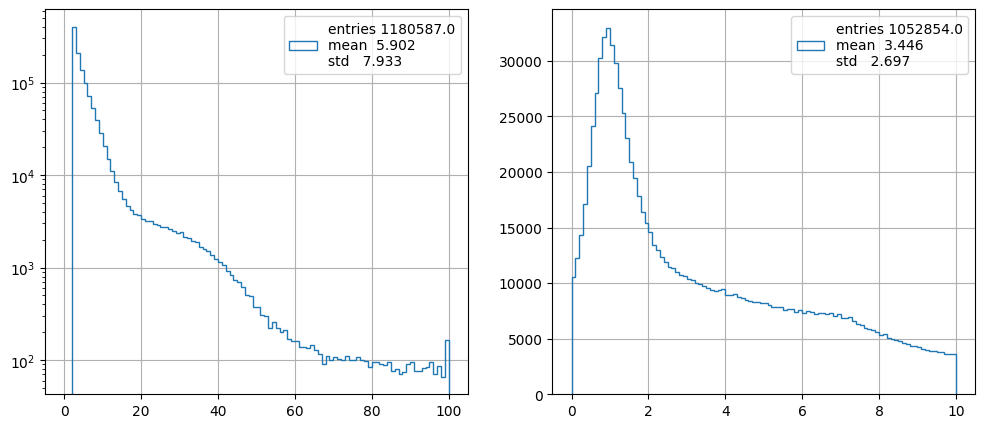

In [13]:
subplot = pltext.canvas(2)

subplot(1)
pltext.hist(hits_per_candidate, 100, ylog=True, range=(0, 100));

subplot(2)
pltext.hist(trms_per_candidate, 100, ylog=False, range=(0,10));

In [27]:
sys.path.append(os.path.abspath(
    os.environ.get("WCTE_SOFTWARE_DIR",
                    "/home/usc/ie/dcr/hk/nicf_analysis/data_analysis/src")
))

from functions import load_pmt_positions, build_tof_map

pmt_positions = load_pmt_positions("/home/usc/ie/dcr/hk/ambe_analysis/AmBe_Data_Analysis/data/wcte_v11_20250513.json")
source_pos = [0, 1525, 0]  # or whatever position for this run
tof_map = build_tof_map(pmt_positions, source_pos, n_water=1.33)

data["hit_pmt_calibrated_times_raw"] = (
    data["hit_pmt_calibrated_times"] + data["pmt_id"].map(tof_map)
)

data["trms_raw"] = data.groupby("candidate_id")["hit_pmt_calibrated_times_raw"].transform("std")

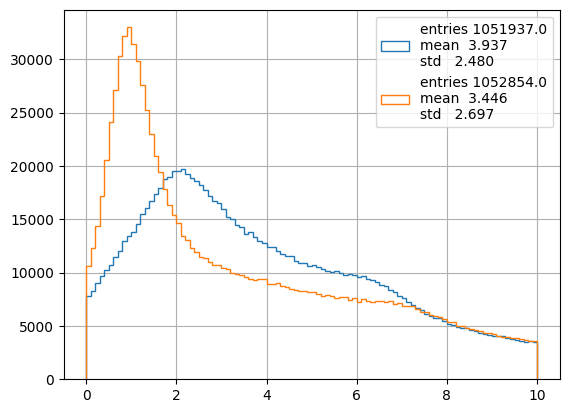

In [28]:
raw_trms_per_candidate = data.groupby("candidate_id")["trms_raw"].first().values

pltext.hist(raw_trms_per_candidate, 100, ylog=False, range=(0,10));
pltext.hist(trms_per_candidate, 100, ylog=False, range=(0,10));

# Actual BONSAI Reconstruction

In [29]:
df_nhits10trms2 = data[(data["nhits"].values > 10) & (data["trms_raw"].values < 6)]

In [33]:
simfile = ROOT.TFile("/home/usc/ie/dcr/hk/nicf_analysis/bonsai_reco/bonsai_reqs/wcsim.root")
simtree = simfile.Get("wcsimGeoT")
geotree = None
for geoevent in simtree:
    geotree = geoevent.wcsimrootgeom
    break
    
bonsai = cppyy.gbl.WCSimBonsai()
bonsai.Init(geotree)

# Start Filter
# ns             = 1
# count          = 0
# nhit_cut       = 10
# mvwindow_start =   10000*ns
# mvwindow_end   = 5000000*ns
# mvwindow_step  =      10*ns
# mvwindow_width =      10*ns

ns             = 1
count          = 0
nhit_cut       = 10
mvwindow_start = 0*ns
mvwindow_end   = 5000000*ns
mvwindow_step  = 10*ns
mvwindow_width = 20*ns

vertex = {
"candidate_id": [],
"nhits": [],
"nhitso": [],
"x": [],
"y": [],
"z": [],
"t_vertex_rel": [],
"result1": [],
"result2": [],
"result3": [],
"result4": [],
"result5": [],
"good0":[],
"good1":[],
"good2":[],
"t_vertex_abs":[] 
}

for df_idx, df in tqdm(enumerate(events), total=len(events)):
    count += 1    
    if count > 50000: break
    # print(count)

    # Generate hit_collection from event
    sub = df_nhits10trms2[df_nhits10trms2.candidate_id == df]
    hits_df = hit_collection(sub)

    # Run a moving average 50ns hit filter
    tstart = mvwindow_start 
    tend   = tstart + mvwindow_width
    try:
        tmax = np.max(hits_df.t)
    except:
        # print(df_idx)
        continue
    
    while tend < tmax:
        
        window = hits_df.time_slice(tstart, tend)
        tstart += mvwindow_step
        tend   = tstart + mvwindow_width
    
        # Run prehit filter for this window
        if len(window.t) < nhit_cut: continue
        if len(window.t) > 400: continue
                
        # Run Bonsai
        bsVertex = array.array('f',3*[0.0])
        bsResult = array.array('f',6*[0.0])
        bsGood = array.array('f',3*[0.0])
        bsNhit = array.array('i',[len(window.cable)])
        bsNsel = array.array('i',[0])

        # Generate hit collection for this triggger
        bsCAB_a = array.array('i', window.cable)
        bsT_a = array.array('f', window.t - np.min(window.t) + 200)
        bsQ_a = array.array('f', window.q)

        # Run Bonsai
        try:
            nhits = bonsai.BonsaiFit(bsVertex, bsResult, bsGood, bsNsel, bsNhit, bsCAB_a, bsT_a, bsQ_a);
        except:
            print("BONSAIFAILED");
            tstart += mvwindow_width
            tend    = tstart + mvwindow_width
            continue
        # print(nhits, bsVertex, bsResult, bsGood, bsNsel, bsNhit)

        vertex["candidate_id"].append(df_idx)
        vertex["nhits"].append(nhits)
        vertex["nhitso"].append(len(window.t))
        
        vertex["x"].append(bsVertex[0])
        vertex["y"].append(bsVertex[1])
        vertex["z"].append(bsVertex[2])
        vertex["t_vertex_rel"].append(bsResult[0])
        vertex["result1"].append(bsResult[1])
        vertex["result2"].append(bsResult[2])
        vertex["result3"].append(bsResult[3])
        vertex["result4"].append(bsResult[4])
        vertex["result5"].append(bsResult[5])
        vertex["good0"].append(bsGood[0])
        vertex["good1"].append(bsGood[1])
        vertex["good2"].append(bsGood[2])
        vertex["t_vertex_abs"].append(bsResult[0] + np.min(window.t) - 200)
        
        # Skip to next window if we found a hit
        tstart += mvwindow_width
        tend    = tstart + mvwindow_width
        
for key in vertex:
    print(key, len(vertex[key]))
    
df = pd.DataFrame(vertex)

  0%|          | 0/1208884 [00:00<?, ?it/s]

  4%|▍         | 50000/1208884 [19:19<7:28:00, 43.11it/s] 

candidate_id 2491
nhits 2491
nhitso 2491
x 2491
y 2491
z 2491
t_vertex_rel 2491
result1 2491
result2 2491
result3 2491
result4 2491
result5 2491
good0 2491
good1 2491
good2 2491
t_vertex_abs 2491
notNuPrism = 0
 Geometry Loading (NPMT=1995) 
Loaded 1995 PMT locations, maximum r=157.713089, maximum z=138.848557
Loading pdfs from /mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/hk-BONSAI/data/like.bin...
Turn on background fitting
pdf for -1.00pe<=q: zero at 730 total=2.086008ns


# BONSAI Reconstruction Restructured
No window selecting, no max hits or things like that; I'm already inputing the signal candidates that I want to be reconstructed.

In [ ]:
simfile = ROOT.TFile("/home/usc/ie/dcr/hk/nicf_analysis/bonsai_reco/bonsai_reqs/wcsim.root")
simtree = simfile.Get("wcsimGeoT")
geotree = None
for geoevent in simtree:
    geotree = geoevent.wcsimrootgeom
    break
    
bonsai = cppyy.gbl.WCSimBonsai()
bonsai.Init(geotree)

# Start Filter
# ns             = 1
# count          = 0
# nhit_cut       = 10
# mvwindow_start =   10000*ns
# mvwindow_end   = 5000000*ns
# mvwindow_step  =      10*ns
# mvwindow_width =      10*ns

ns             = 1
count          = 0
nhit_cut       = 10
mvwindow_start = 0*ns
mvwindow_end   = 5000000*ns
mvwindow_step  = 10*ns
mvwindow_width = 20*ns

vertex = {
"candidate_id": [],
"nhits": [],
"nhitso": [],
"x": [],
"y": [],
"z": [],
"t_vertex_rel": [],
"result1": [],
"result2": [],
"result3": [],
"result4": [],
"result5": [],
"good0":[],
"good1":[],
"good2":[],
"t_vertex_abs":[] 
}

for df_idx, df in tqdm(enumerate(events), total=len(events)):

    # count += 1    
    # if count > 10000: break

    sub     = data[data.candidate_id == df]
    hits_df = hit_collection(sub)

    if len(hits_df.t) == 0:
        # print(df_idx)
        continue

    # Usa el candidato entero, sin ventana deslizante
    window = hits_df.time_slice(np.min(hits_df.t) - 1, np.max(hits_df.t) + 1)

    if len(window.t) < nhit_cut: continue
    if len(window.t) > 400:      continue

    bsVertex = array.array('f', 3*[0.0])
    bsResult = array.array('f', 6*[0.0])
    bsGood   = array.array('f', 3*[0.0])
    bsNhit   = array.array('i', [len(window.cable)])
    bsNsel   = array.array('i', [0])

    bsCAB_a = array.array('i', window.cable)
    bsT_a   = array.array('f', window.t - np.min(window.t) + 200)
    bsQ_a   = array.array('f', window.q)

    try:
        nhits = bonsai.BonsaiFit(bsVertex, bsResult, bsGood, bsNsel, bsNhit, bsCAB_a, bsT_a, bsQ_a)
    except:
        # print("BONSAIFAILED")
        continue

    vertex["candidate_id"].append(df_idx)
    vertex["nhits"].append(nhits)
    vertex["nhitso"].append(len(window.t))
    vertex["x"].append(bsVertex[0])
    vertex["y"].append(bsVertex[1])
    vertex["z"].append(bsVertex[2])
    vertex["t_vertex_rel"].append(bsResult[0])
    vertex["result1"].append(bsResult[1])
    vertex["result2"].append(bsResult[2])
    vertex["result3"].append(bsResult[3])
    vertex["result4"].append(bsResult[4])
    vertex["result5"].append(bsResult[5])
    vertex["good0"].append(bsGood[0])
    vertex["good1"].append(bsGood[1])
    vertex["good2"].append(bsGood[2])
    vertex["t_vertex_abs"].append(bsResult[0] + np.min(window.t) - 200)

for key in vertex:
    print(key, len(vertex[key]))
    
df_new = pd.DataFrame(vertex)

  1%|          | 521/95423 [00:02<07:41, 205.52it/s]

496


  1%|          | 625/95423 [00:03<08:36, 183.56it/s]

591


  2%|▏         | 1452/95423 [00:07<08:25, 185.90it/s]

...

94113


100%|█████████▉| 95365/95423 [08:39<00:00, 182.51it/s]

95339


100%|██████████| 95423/95423 [08:39<00:00, 183.60it/s]


candidate_id 19475
nhits 19475
nhitso 19475
x 19475
y 19475
z 19475
t_vertex_rel 19475
result1 19475
result2 19475
result3 19475
result4 19475
result5 19475
good0 19475
good1 19475
good2 19475
t_vertex_abs 19475
notNuPrism = 0
 Geometry Loading (NPMT=1995) 
Loaded 1995 PMT locations, maximum r=157.713089, maximum z=138.848557
Loading pdfs from /mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/hk-BONSAI/data/like.bin...
Turn on background fitting
pdf for -1.00pe<=q: zero at 730 total=2.086008ns


# Plot Results

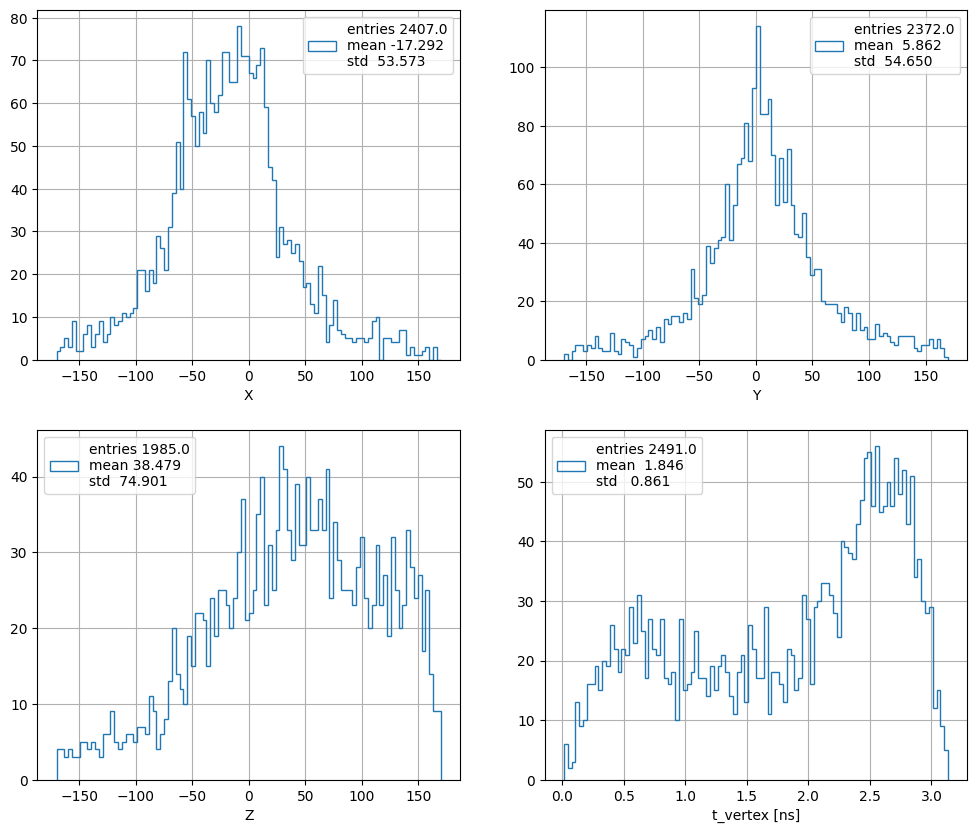

In [34]:
subplot = pltext.canvas(4)

subplot(1)
# pltext.hist(df_reco.x, 100, range=(-170, 170));
pltext.hist(df.x, 100, range=(-170, 170), xylabels="X");

subplot(2)
# pltext.hist(df_reco.y, 100, range=(-170, 170));
pltext.hist(df.y, 100, range=(-170, 170), xylabels="Y");

subplot(3)
# pltext.hist(df_reco.z, 100, range=(-170, 170));
pltext.hist(df.z, 100, range=(-170, 170), xylabels="Z");

subplot(4)
# pltext.hist(df_reco.t_vertex_rel, 100);
pltext.hist(df.t_vertex_rel, 100, xylabels="t_vertex [ns]");

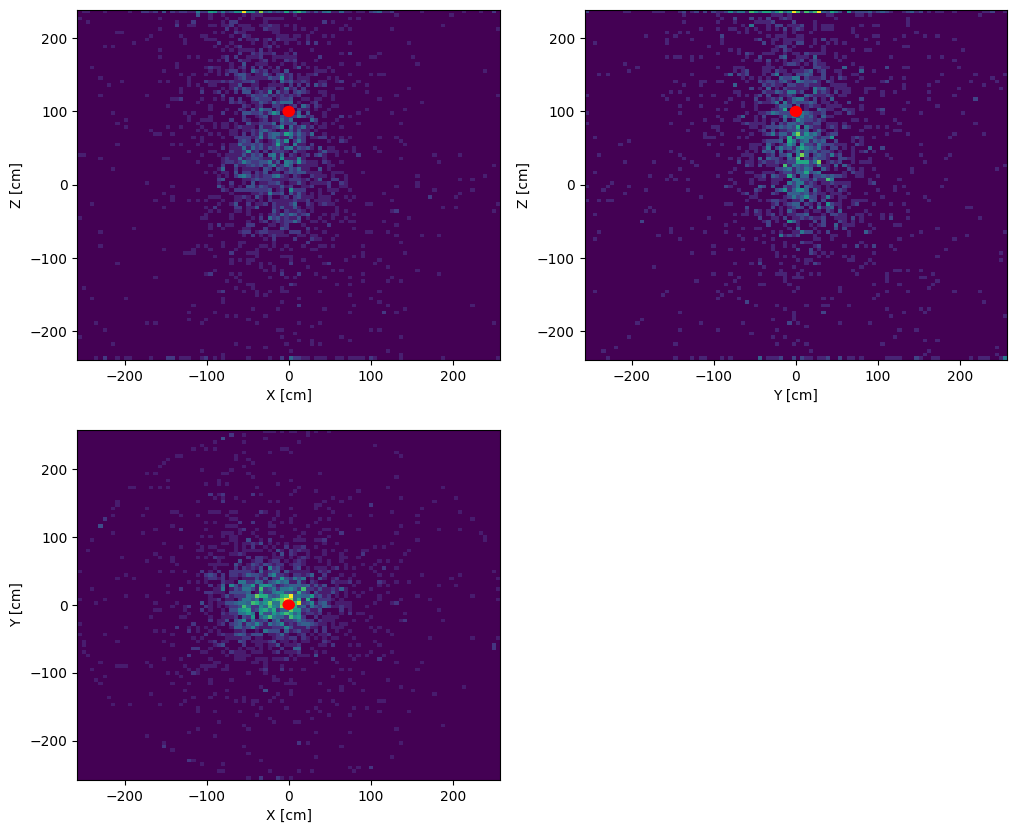

In [35]:
subplot = pltext.canvas(3)

rho = 0
phi = 0
phi_prime = 0
z   = 100

source_x = rho*np.cos(phi_prime)
source_y = rho*np.sin(phi_prime)
source_z = z
source_r = 6.75

subplot(1)
plt.hist2d(df["x"], df["z"], bins=(100, 100));
circle = plt.Circle((source_x, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]");
plt.ylabel("Z [cm]");

subplot(2)
plt.hist2d(df["y"], df["z"], bins=(100, 100));
circle = plt.Circle((source_y, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("Y [cm]");
plt.ylabel("Z [cm]");

subplot(3)
plt.hist2d(df["x"], df["y"], bins=(100, 100));
circle = plt.Circle((source_x, source_y), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]");
plt.ylabel("Y [cm]");

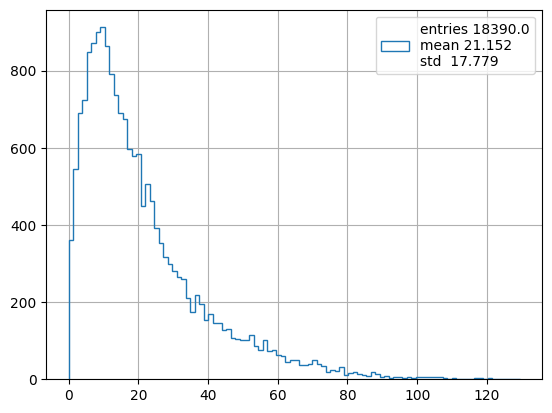

In [31]:
# pltext.hist(df_reco["good1"], 100, ylog=True);
# pltext.hist(df_reco["good2"], 100, ylog=True);
pltext.hist([i for i in df_new["good0"] if i>0], 100, ylog=False);

In [7]:
df.to_csv("1767_usingOldCode_DataTcQ2020nsWinCut_Just10kCounts.csv")

In [8]:
df

,candidate,nhits,nhitso,x,y,z,t_vertex_rel,result1,result2,result3,result4,result5,good0,good1,good2,t_vertex_abs
